In [ ]:
%pip install -q --upgrade pip setuptools wheel
%pip install -q numpy pandas matplotlib soundfile scipy imageio-ffmpeg
%pip install -q numba==0.60.0 llvmlite==0.43.0 librosa==0.10.2.post1

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from pathlib import Path
import re
import subprocess
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import soundfile as sf
import imageio_ffmpeg

PROJECT_ROOT = Path.cwd()
CANDIDATE_RAW_DIRS = [
    PROJECT_ROOT / 'data' / 'audio' / 'raw',
    Path('/Users/michaelkimani/Desktop/ Group Audios'),
]
existing_candidates = [p for p in CANDIDATE_RAW_DIRS if p.exists()]
if existing_candidates:
    RAW_DIR = max(existing_candidates, key=lambda p: len([x for x in p.glob('*') if x.is_file()]))
else:
    RAW_DIR = CANDIDATE_RAW_DIRS[0]
OUTPUT_ROOT = PROJECT_ROOT
RAW_COPY_DIR = OUTPUT_ROOT / 'data' / 'audio' / 'raw'
WAV_DIR = OUTPUT_ROOT / 'data' / 'audio' / 'processed' / 'wav'
AUG_DIR = OUTPUT_ROOT / 'data' / 'audio' / 'processed' / 'augmentations'
FEATURES_DIR = OUTPUT_ROOT / 'features'
FEATURES_CSV = FEATURES_DIR / 'audio_features.csv'
FFMPEG_BIN = imageio_ffmpeg.get_ffmpeg_exe()

for p in [RAW_COPY_DIR, WAV_DIR, AUG_DIR, FEATURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

if not RAW_DIR.exists():
    raise FileNotFoundError(
        f'No input audio folder found. Checked: {CANDIDATE_RAW_DIRS}. '
        'Create data/audio/raw in the project or update the fallback path.'
    )

TARGET_SR = 16000
N_MFCC = 13
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('Project root:', PROJECT_ROOT)
print('Raw input folder:', RAW_DIR)
print('Output root:', OUTPUT_ROOT)
print('FFmpeg binary:', FFMPEG_BIN)

Project root: /Users/michaelkimani/Downloads
Raw input folder: /Users/michaelkimani/Desktop/ Group Audios
Output root: /Users/michaelkimani/Downloads
FFmpeg binary: /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/imageio_ffmpeg/binaries/ffmpeg-macos-x86_64-v7.1


In [ ]:
def normalize_text(value: str) -> str:
    text = value.lower().strip()
    text = text.replace(',', ' ')
    text = re.sub(r'\s+', ' ', text)
    return text

def infer_phrase_label(filename: str) -> str:
    text = normalize_text(filename)
    if 'yes approve' in text or 'yes, approve' in text:
        return 'yes_approve'
    if 'confirm transaction' in text or 'confirm transcation' in text:
        return 'confirm_transaction'
    return 'unknown'

def infer_member_name(filename: str) -> str:
    base = re.sub(r'\.[^.]+$', '', filename).strip()
    phrase_patterns = [
        r'\byes\b\s*,?\s*\bapprove\b',
        r'\bconfirm\b\s*\btranscation\b',
        r'\bconfirm\b\s*\btransaction\b',
    ]
    member = base
    for pat in phrase_patterns:
        member = re.sub(pat, '', member, flags=re.IGNORECASE).strip()
    member = re.sub(r'\s+', ' ', member)
    return member

source_files = sorted([p for p in RAW_DIR.glob('*') if p.is_file()])
records = []
for path in source_files:
    phrase = infer_phrase_label(path.name)
    member = infer_member_name(path.name)
    records.append({
        'source_path': str(path),
        'source_name': path.name,
        'member': member,
        'phrase_label': phrase,
        'ext': path.suffix.lower(),
    })

files_df = pd.DataFrame(records)
display(files_df)
print('Total input files:', len(files_df))
print(files_df.groupby(['member', 'phrase_label']).size().reset_index(name='count'))

,source_path,source_name,member,phrase_label,ext
0,/Users/michaelkimani/Desktop/ Group Audios/ Da...,David Confirm transaction.m4a,David,confirm_transaction,.m4a
1,/Users/michaelkimani/Desktop/ Group Audios/ Da...,"David Yes, approve.m4a",David,yes_approve,.m4a
2,/Users/michaelkimani/Desktop/ Group Audios/Kel...,Kelvin Confirm transcation.mp4,Kelvin,confirm_transaction,.mp4
3,/Users/michaelkimani/Desktop/ Group Audios/Kel...,Kelvin Yes Approve.mp4,Kelvin,yes_approve,.mp4
4,/Users/michaelkimani/Desktop/ Group Audios/Mic...,Michael Kimani Confirm transcation.opus,Michael Kimani,confirm_transaction,.opus
5,/Users/michaelkimani/Desktop/ Group Audios/Mic...,Michael Kimani Yes Approve.opus,Michael Kimani,yes_approve,.opus
6,/Users/michaelkimani/Desktop/ Group Audios/Sam...,Samuel Confirm transcation.mpeg,Samuel,confirm_transaction,.mpeg
7,/Users/michaelkimani/Desktop/ Group Audios/Sam...,Samuel Yes Approve.mpeg,Samuel,yes_approve,.mpeg


Total input files: 8
           member         phrase_label  count
0           David  confirm_transaction      1
1           David          yes_approve      1
2          Kelvin  confirm_transaction      1
3          Kelvin          yes_approve      1
4  Michael Kimani  confirm_transaction      1
5  Michael Kimani          yes_approve      1
6          Samuel  confirm_transaction      1
7          Samuel          yes_approve      1


In [ ]:
def convert_to_wav(src_path: Path, dst_path: Path, target_sr: int = 16000):
    cmd = [
        FFMPEG_BIN, '-y', '-i', str(src_path),
        '-ac', '1', '-ar', str(target_sr), str(dst_path)
    ]
    result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    if result.returncode != 0:
        raise RuntimeError(f'ffmpeg failed for {src_path.name}: {result.stderr[-300:]}')

converted = []
for row in files_df.itertuples(index=False):
    src = Path(row.source_path)
    safe_stem = re.sub(r'\s+', '_', re.sub(r'[^a-zA-Z0-9_\- ]', '', src.stem.strip()))
    wav_name = f"{safe_stem}.wav"
    wav_path = WAV_DIR / wav_name
    copy_path = RAW_COPY_DIR / src.name
    if not copy_path.exists():
        copy_path.write_bytes(src.read_bytes())
    convert_to_wav(src, wav_path, TARGET_SR)
    converted.append({
        'member': row.member,
        'phrase_label': row.phrase_label,
        'source_name': row.source_name,
        'wav_path': str(wav_path),
        'sample_type': 'original',
    })

audio_df = pd.DataFrame(converted)
display(audio_df.head())
print('Converted files:', len(audio_df))

,member,phrase_label,source_name,wav_path,sample_type
0,David,confirm_transaction,David Confirm transaction.m4a,/Users/michaelkimani/Downloads/data/audio/proc...,original
1,David,yes_approve,"David Yes, approve.m4a",/Users/michaelkimani/Downloads/data/audio/proc...,original
2,Kelvin,confirm_transaction,Kelvin Confirm transcation.mp4,/Users/michaelkimani/Downloads/data/audio/proc...,original
3,Kelvin,yes_approve,Kelvin Yes Approve.mp4,/Users/michaelkimani/Downloads/data/audio/proc...,original
4,Michael Kimani,confirm_transaction,Michael Kimani Confirm transcation.opus,/Users/michaelkimani/Downloads/data/audio/proc...,original


Converted files: 8


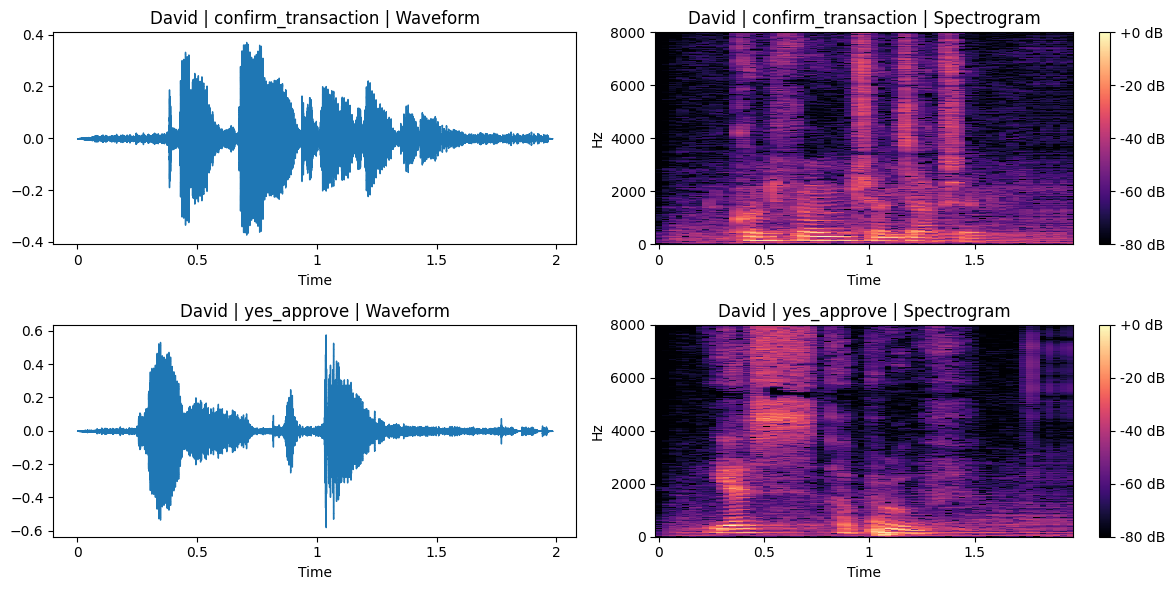

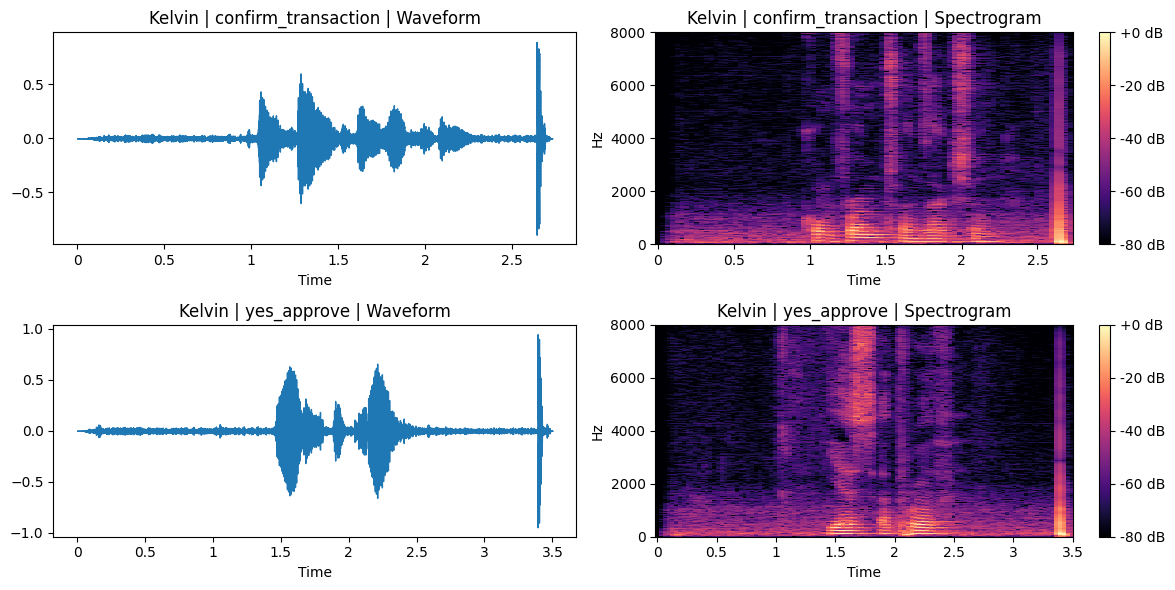

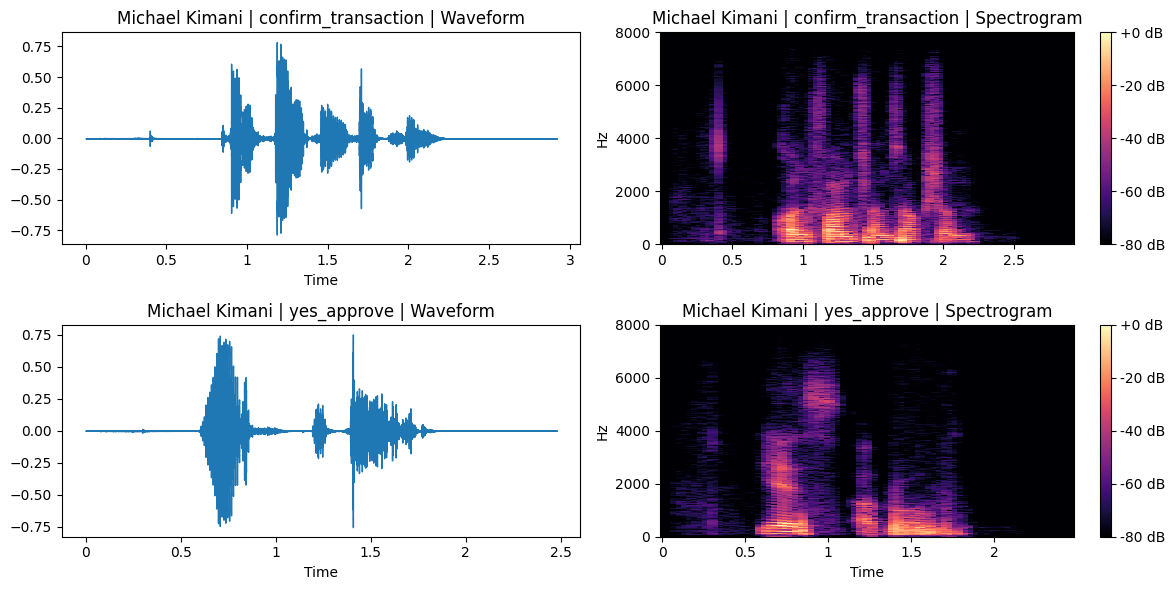

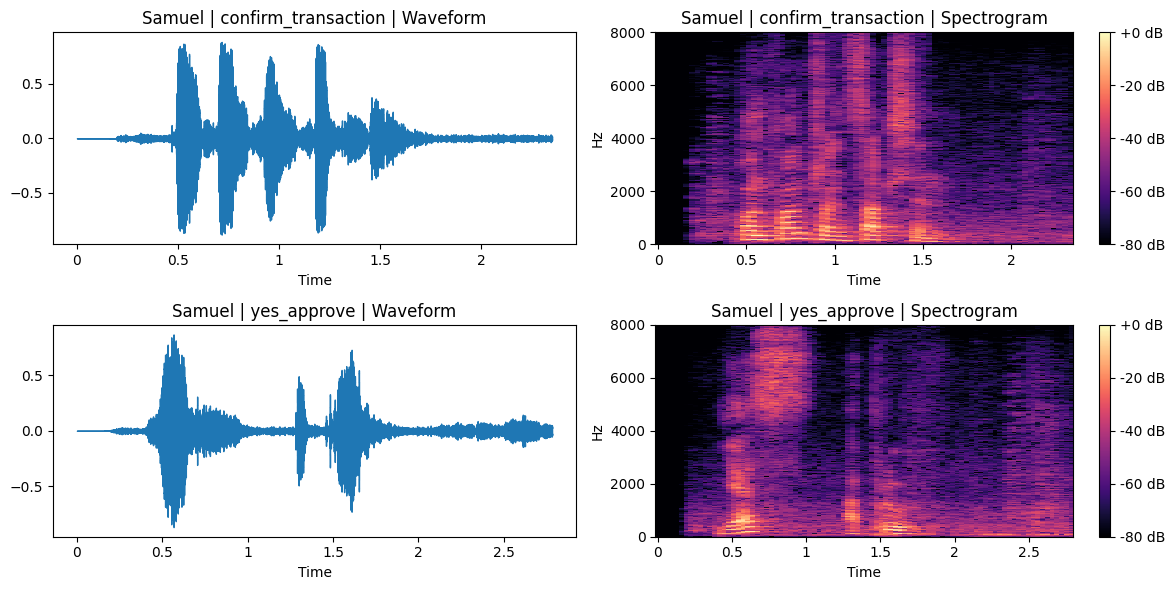

In [ ]:
members = sorted(audio_df['member'].unique())
for member in members:
    subset = audio_df[audio_df['member'] == member].sort_values('phrase_label')
    if subset.empty:
        continue
    fig, axes = plt.subplots(len(subset), 2, figsize=(12, 3 * len(subset)))
    if len(subset) == 1:
        axes = np.array([axes])
    for i, row in enumerate(subset.itertuples(index=False)):
        y, sr = librosa.load(row.wav_path, sr=TARGET_SR)
        librosa.display.waveshow(y, sr=sr, ax=axes[i, 0])
        axes[i, 0].set_title(f"{member} | {row.phrase_label} | Waveform")
        S = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
        img = librosa.display.specshow(S, sr=sr, x_axis='time', y_axis='hz', ax=axes[i, 1])
        axes[i, 1].set_title(f"{member} | {row.phrase_label} | Spectrogram")
        fig.colorbar(img, ax=axes[i, 1], format='%+2.0f dB')
    plt.tight_layout()
    plt.show()

## Quick Interpretation (Audio Plots)

- Most clips have clear speech activity in the middle and low energy at the start/end.
- Spectrograms show stronger energy in lower frequencies during spoken words.
- The two phrases are visually similar in some parts, but timing and energy patterns still vary by sample.
- Minor background noise is present in a few clips, but speech remains usable for feature extraction.
- Overall, waveform and spectrogram quality is sufficient for augmentation and MFCC-based modeling.

In [ ]:
def augment_time_stretch(y: np.ndarray, rate: float = 1.1) -> np.ndarray:
    return librosa.effects.time_stretch(y, rate=rate)

def augment_pitch_shift(y: np.ndarray, sr: int, n_steps: float = 2.0) -> np.ndarray:
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)

def augment_add_noise(y: np.ndarray, noise_level: float = 0.003) -> np.ndarray:
    noise = np.random.randn(len(y))
    return (y + noise_level * noise).astype(np.float32)

def extract_features(y: np.ndarray, sr: int, member: str, phrase_label: str, sample_type: str, file_name: str) -> dict:
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    rms = librosa.feature.rms(y=y)
    zcr = librosa.feature.zero_crossing_rate(y)
    features = {
        'member': member,
        'phrase_label': phrase_label,
        'sample_type': sample_type,
        'file_name': file_name,
        'duration_sec': len(y) / sr,
        'spectral_rolloff_mean': float(np.mean(rolloff)),
        'spectral_rolloff_std': float(np.std(rolloff)),
        'energy_rms_mean': float(np.mean(rms)),
        'energy_rms_std': float(np.std(rms)),
        'zero_crossing_rate_mean': float(np.mean(zcr)),
        'zero_crossing_rate_std': float(np.std(zcr)),
    }
    for i in range(N_MFCC):
        features[f'mfcc_{i+1}_mean'] = float(np.mean(mfcc[i]))
        features[f'mfcc_{i+1}_std'] = float(np.std(mfcc[i]))
    return features

In [ ]:
feature_rows = []
augmented_records = []

for row in audio_df.itertuples(index=False):
    y, sr = librosa.load(row.wav_path, sr=TARGET_SR)

    original_name = Path(row.wav_path).name
    feature_rows.append(
        extract_features(
            y=y, sr=sr, member=row.member, phrase_label=row.phrase_label,
            sample_type='original', file_name=original_name
        )
    )

    y_stretch = augment_time_stretch(y, rate=1.1)
    stretch_name = Path(row.wav_path).stem + '_aug_time_stretch.wav'
    stretch_path = AUG_DIR / stretch_name
    sf.write(stretch_path, y_stretch, sr)
    feature_rows.append(
        extract_features(
            y=y_stretch, sr=sr, member=row.member, phrase_label=row.phrase_label,
            sample_type='aug_time_stretch', file_name=stretch_name
        )
    )
    augmented_records.append({'member': row.member, 'phrase_label': row.phrase_label, 'aug_file': str(stretch_path)})

    y_pitch = augment_pitch_shift(y, sr=sr, n_steps=2.0)
    pitch_name = Path(row.wav_path).stem + '_aug_pitch_shift.wav'
    pitch_path = AUG_DIR / pitch_name
    sf.write(pitch_path, y_pitch, sr)
    feature_rows.append(
        extract_features(
            y=y_pitch, sr=sr, member=row.member, phrase_label=row.phrase_label,
            sample_type='aug_pitch_shift', file_name=pitch_name
        )
    )
    augmented_records.append({'member': row.member, 'phrase_label': row.phrase_label, 'aug_file': str(pitch_path)})

    y_noise = augment_add_noise(y, noise_level=0.003)
    noise_name = Path(row.wav_path).stem + '_aug_noise.wav'
    noise_path = AUG_DIR / noise_name
    sf.write(noise_path, y_noise, sr)
    feature_rows.append(
        extract_features(
            y=y_noise, sr=sr, member=row.member, phrase_label=row.phrase_label,
            sample_type='aug_noise', file_name=noise_name
        )
    )
    augmented_records.append({'member': row.member, 'phrase_label': row.phrase_label, 'aug_file': str(noise_path)})

features_df = pd.DataFrame(feature_rows)
features_df.to_csv(FEATURES_CSV, index=False)
aug_df = pd.DataFrame(augmented_records)

print('Saved features:', FEATURES_CSV)
print('Feature rows:', len(features_df))
display(features_df.head())

Saved features: /Users/michaelkimani/Downloads/features/audio_features.csv
Feature rows: 32


,member,phrase_label,sample_type,file_name,duration_sec,spectral_rolloff_mean,spectral_rolloff_std,energy_rms_mean,energy_rms_std,zero_crossing_rate_mean,...,mfcc_9_mean,mfcc_9_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std
0,David,confirm_transaction,original,David_Confirm_transaction.wav,1.982687,3342.741935,1646.974610,0.043904,0.038651,0.106981,...,-9.664478,7.972005,-11.377956,10.062860,-5.597507,8.092649,-7.987700,5.954972,-1.099546,6.100213
1,David,confirm_transaction,aug_time_stretch,David_Confirm_transaction_aug_time_stretch.wav,1.802437,3664.884868,1511.515134,0.029109,0.023926,0.104526,...,-10.436193,9.226603,-11.936535,10.939840,-5.351406,6.715860,-8.226660,6.420238,0.020772,4.124268
2,David,confirm_transaction,aug_pitch_shift,David_Confirm_transaction_aug_pitch_shift.wav,1.982687,3383.694556,1436.035167,0.027341,0.021365,0.111643,...,-14.761172,9.614007,-6.024604,7.176507,-7.362373,7.208771,-0.887781,5.564206,1.925244,7.004286
3,David,confirm_transaction,aug_noise,David_Confirm_transaction_aug_noise.wav,1.982687,4845.640121,1755.619536,0.044224,0.038397,0.167559,...,-8.842916,8.398547,-11.030150,9.214702,-6.310654,6.677911,-6.692425,6.070935,-2.174157,5.389391
4,David,yes_approve,original,David_Yes_approve.wav,1.982687,3983.240927,2235.668564,0.048300,0.054538,0.155872,...,-5.775816,7.865860,-5.848888,15.751942,2.754930,6.719128,-4.944895,8.722790,-0.862086,9.547696


In [ ]:
required = features_df.groupby(['member', 'phrase_label'])['sample_type'].nunique().reset_index(name='unique_sample_types')
display(required.sort_values(['member', 'phrase_label']))

print('Original files per member:')
print(audio_df.groupby('member').size())

print('Phrase coverage:')
print(audio_df.groupby('phrase_label').size())

print('Augmented files created:', len(aug_df))
print('CSV exists:', FEATURES_CSV.exists())

,member,phrase_label,unique_sample_types
0,David,confirm_transaction,4
1,David,yes_approve,4
2,Kelvin,confirm_transaction,4
3,Kelvin,yes_approve,4
4,Michael Kimani,confirm_transaction,4
5,Michael Kimani,yes_approve,4
6,Samuel,confirm_transaction,4
7,Samuel,yes_approve,4


Original files per member:
member
David             2
Kelvin            2
Michael Kimani    2
Samuel            2
dtype: int64
Phrase coverage:
phrase_label
confirm_transaction    4
yes_approve            4
dtype: int64
Augmented files created: 24
CSV exists: True
